In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)
%matplotlib inline

In [3]:
extract_path = "/content/drive/MyDrive/wheat_leaf_combined"
if os.path.exists(extract_path):
    print("Extracted files:", os.listdir(extract_path))
else:
    print("Extraction failed or path incorrect.")

Extracted files: ['Testing', 'Training', 'Validation']


In [4]:
for root, dirs, files in os.walk("/content/drive/MyDrive/wheat_leaf_combined"):
    print(root, dirs, files)

/content/drive/MyDrive/wheat_leaf_combined ['Testing', 'Training', 'Validation'] []
/content/drive/MyDrive/wheat_leaf_combined/Testing ['Septoria Combined', 'Healthy Combined', 'Stripe Rust Combined'] []
/content/drive/MyDrive/wheat_leaf_combined/Testing/Septoria Combined [] ['los(63).JPG', 'los(85).JPG', 'los(88).JPG', 'los(86).JPG', 'los(74).JPG', 'los(87).JPG', 'los(94).JPG', 'los(95).JPG', 'los(97).JPG', 'los(96).JPG', 'septoria_reconst_10.png', 'septoria_reconst_21.png', 'septoria_reconst_32.png', 'septoria_reconst_43.png', 'septoria_reconst_54.png', 'septoria_reconst_92.png', 'septoria_reconst_91.png', 'septoria_reconst_93.png', 'septoria_reconst_94.png', 'septoria_reconst_95.png']
/content/drive/MyDrive/wheat_leaf_combined/Testing/Healthy Combined [] ['loh(100).JPG', 'loh(101).JPG', 'loh(102).JPG', 'loh(94).JPG', 'loh(96).JPG', 'loh(93).JPG', 'loh(95).JPG', 'loh(97).JPG', 'loh(98).JPG', 'loh(99).JPG', 'healthy_reconst_10.png', 'healthy_reconst_21.png', 'healthy_reconst_32.png', 

In [5]:
training_path='/content/drive/MyDrive/wheat_leaf_combined/Training'
validation_path='/content/drive/MyDrive/wheat_leaf_combined/Validation'
testing_path='/content/drive/MyDrive/wheat_leaf_combined/Testing'

In [6]:
print("Training path:", training_path)
print("Validation path:", validation_path)
print("Testing path:", testing_path)

Training path: /content/drive/MyDrive/wheat_leaf_combined/Training
Validation path: /content/drive/MyDrive/wheat_leaf_combined/Validation
Testing path: /content/drive/MyDrive/wheat_leaf_combined/Testing


In [10]:
# train_batches=ImageDataGenerator(
#     preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(
#         training_path, target_size=(224,224), classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'], batch_size=64)

# valid_batches=ImageDataGenerator(
#     preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(
#         validation_path, target_size=(224,224), classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'], batch_size=64)

# test_batches=ImageDataGenerator(
#     preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(
#         testing_path, target_size=(224,224), classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'], batch_size=64)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Data augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/test
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_batches = train_datagen.flow_from_directory(
    training_path,
    target_size=(224, 224),
    classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'],
    batch_size=64,
    class_mode='categorical'
)

valid_batches = val_test_datagen.flow_from_directory(
    validation_path,
    target_size=(224, 224),
    classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'],
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_batches = val_test_datagen.flow_from_directory(
    testing_path,
    target_size=(224, 224),
    classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'],
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 480 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [11]:

# plots images with labels within jupyter notebook
def plots(ims, figsize=(12,6), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [ ]:
imgs, labels = next(train_batches)

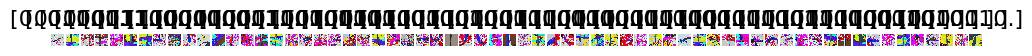

In [ ]:
plots(imgs, titles=labels)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

model = Sequential([
    # Block 1
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3),
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(32, (3, 3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(54, (3, 3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classifier Head
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.001))  # Output layer
])


In [18]:
model.compile(Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor
    patience=10,             # Number of epochs to wait after no improvement
    verbose=1,              # Verbosity mode
    restore_best_weights=True # Restore the best weights after stopping
)

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 54)     │        15,606 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 54)     │           216 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 54)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 42336)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    10,838,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,860,145 (41.43 MB)

 Trainable params: 10,859,941 (41.43 MB)

 Non-trainable params: 204 (816.00 B)

In [21]:
model.fit(train_batches, validation_data=valid_batches, epochs=200, verbose=2)


Epoch 1/200
8/8 - 53s - 7s/step - accuracy: 0.5854 - loss: 83.4230 - val_accuracy: 0.4667 - val_loss: 1163.6530
Epoch 2/200
8/8 - 42s - 5s/step - accuracy: 0.7750 - loss: 60.5194 - val_accuracy: 0.3500 - val_loss: 2583.6121
Epoch 3/200
8/8 - 41s - 5s/step - accuracy: 0.8646 - loss: 43.3814 - val_accuracy: 0.4500 - val_loss: 583.1741
Epoch 4/200
8/8 - 44s - 5s/step - accuracy: 0.8771 - loss: 43.7405 - val_accuracy: 0.5667 - val_loss: 530.8785
Epoch 5/200
8/8 - 43s - 5s/step - accuracy: 0.8958 - loss: 44.0168 - val_accuracy: 0.5833 - val_loss: 417.5673
Epoch 6/200
8/8 - 44s - 5s/step - accuracy: 0.9083 - loss: 39.0147 - val_accuracy: 0.4500 - val_loss: 344.0216
Epoch 7/200
8/8 - 41s - 5s/step - accuracy: 0.9042 - loss: 37.1248 - val_accuracy: 0.3500 - val_loss: 358.4635
Epoch 8/200
8/8 - 42s - 5s/step - accuracy: 0.9292 - loss: 36.3937 - val_accuracy: 0.5333 - val_loss: 194.7205
Epoch 9/200
8/8 - 42s - 5s/step - accuracy: 0.9187 - loss: 34.2850 - val_accuracy: 0.5667 - val_loss: 173.0190

In [22]:
print(f"Stopped at epoch: {early_stopping.stopped_epoch}")

Stopped at epoch: 0


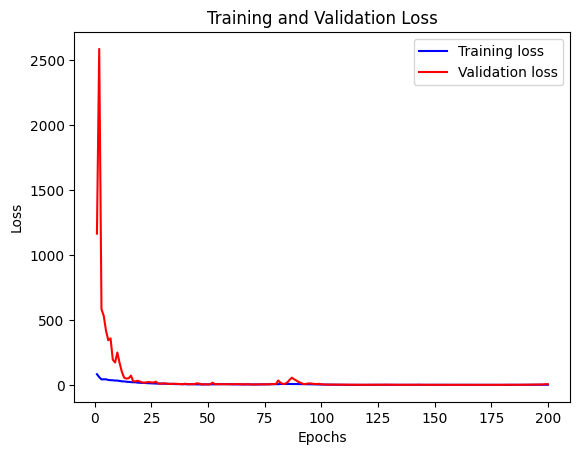

In [23]:
# prompt: plot training, testing and validation loss

import matplotlib.pyplot as plt

# Assuming 'history' object contains the training history from model.fit
# history = model.fit(...)

# Access the loss values
training_loss = model.history.history['loss']
validation_loss = model.history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(training_loss) + 1)  # Assuming epochs are available

plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


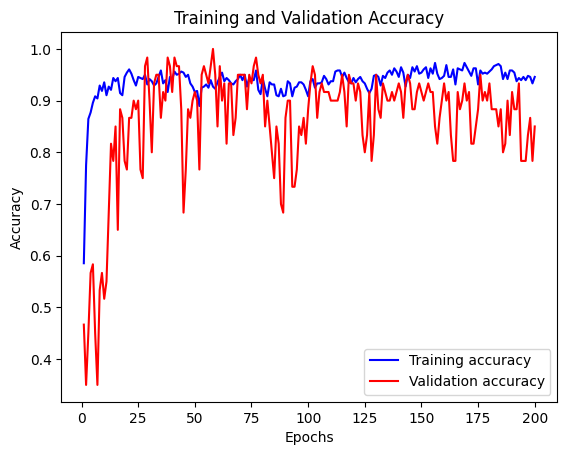

In [24]:
# Plot training and validation accuracy
training_accuracy = model.history.history['accuracy']
validation_accuracy = model.history.history['val_accuracy']

plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [25]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Training Loss: 2.0168
Training Accuracy: 96.25%
Validation Loss: 5.8556
Validation Accuracy: 85.00%
Test Loss: 9.0977
Test Accuracy: 91.67%


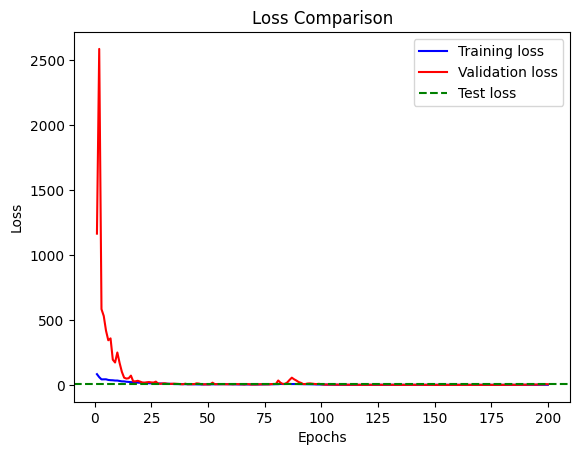

In [26]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

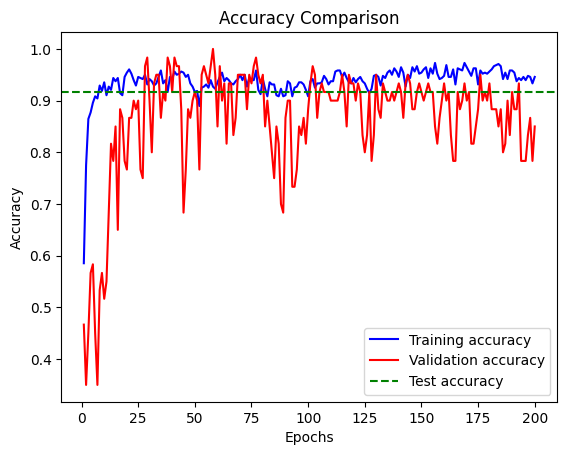

In [27]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
test_imgs, test_labels = next(test_batches)

# Get the model predictions
predictions = model.predict(test_imgs)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Print actual vs predicted labels (indices)
print(f"Actual labels: {test_labels}")
print(f"Predicted labels (indices): {predicted_classes}")

# Optionally, print the class names:
class_names = ['Healthy', 'Septoria', 'Stripe_rust']
predicted_class_names = [class_names[i] for i in predicted_classes]
print(f"Predicted class names: {predicted_class_names}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
Actual labels: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Predicted labels (indices): [0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2]
Predicted class names: ['Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healt

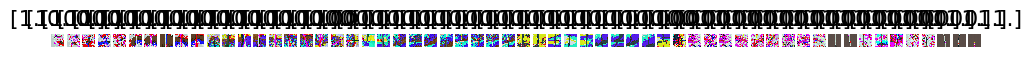

In [29]:
test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [30]:
test_labels = test_labels[:,0]
test_labels

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [31]:
predictions = model.predict(test_batches, steps=1, verbose=0)

In [32]:
predictions.round(2)

array([[0.99, 0.  , 0.01],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [0.96, 0.  , 0.04],
       [0.19, 0.47, 0.34],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.93, 0.  , 0.07],
       [0.52, 0.01, 0.47],
       [0.92, 0.  , 0.08],
       [0.78, 0.  , 0.22],
       [0.  , 1.  , 0.  ],
       [0.99, 0.  , 0.01],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
 

In [33]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

In [34]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [35]:
print("Training classes:", os.listdir(training_path))
print("Validation classes:", os.listdir(validation_path))
print("Testing classes:", os.listdir(testing_path))


Training classes: ['Stripe Rust Combined', 'Septoria Combined', 'Healthy Combined']
Validation classes: ['Septoria Combined', 'Healthy Combined', 'Stripe Rust Combined']
Testing classes: ['Septoria Combined', 'Healthy Combined', 'Stripe Rust Combined']


Confusion matrix, without normalization
[[ 1 20 19]
 [16  4  0]
 [ 0  0  0]]


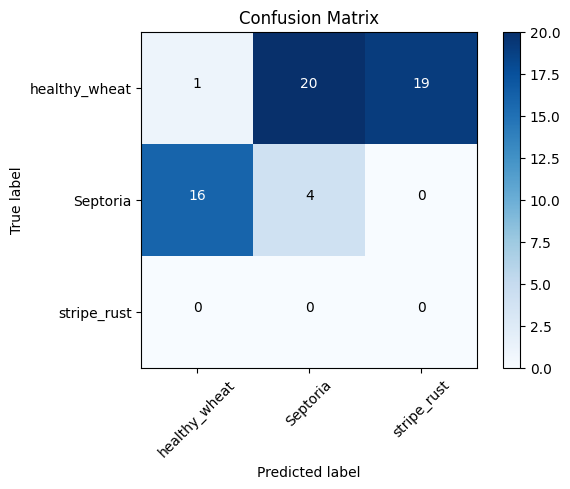

In [37]:
cm_plot_labels = ['healthy_wheat','Septoria','stripe_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [38]:
vgg16_model = keras.applications.vgg16.VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [39]:
vgg16_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
type(vgg16_model)

keras.src.models.functional.Functional

In [41]:

model = Sequential()
for layer in vgg16_model.layers:
    model.add(layer)

In [42]:

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.layers.pop()

<Dense name=predictions, built=True>

In [44]:
for layer in model.layers:
    layer.trainable = False

In [45]:
model.add(Dense(3, activation='softmax'))

In [46]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,360,547 (527.80 MB)

 Trainable params: 3,003 (11.73 KB)

 Non-trainable params: 138,357,544 (527.79 MB)

In [47]:
model.compile(Adam(learning_rate=.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [1]:
history = model.fit(train_batches, validation_data=valid_batches, epochs=200, callbacks=[early_stopping], verbose=2)


NameError: name 'model' is not defined

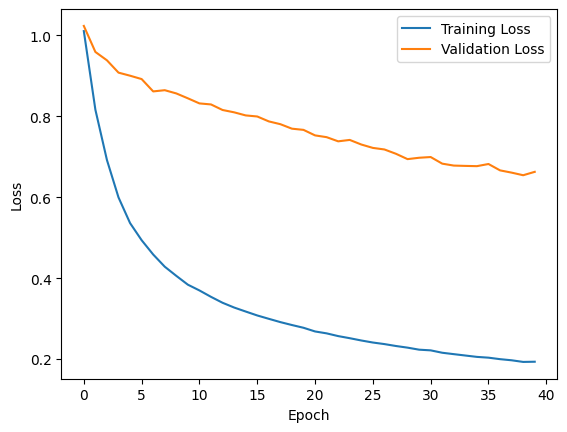

In [ ]:
# prompt: Plot training and validation loss

# Plot training and validation loss
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


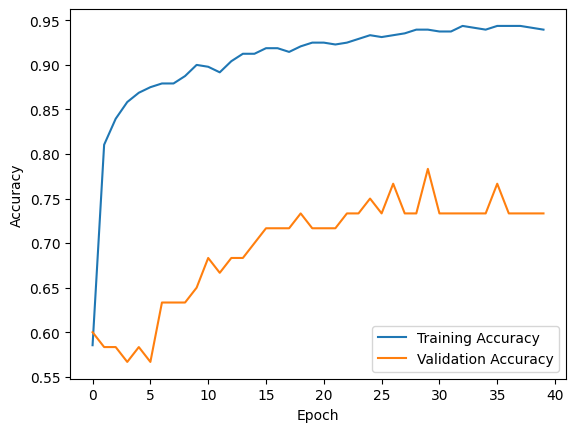

In [ ]:
# prompt: plot training an validation accuracy

# Plot training and validation accuracy
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss on VGG16: {train_loss:.4f}")
print(f"Training Accuracy on VGG16: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss on VGG16: {val_loss:.4f}")
print(f"Validation Accuracy on VGG16: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss on VGG16: {test_loss:.4f}")
print(f"Test Accuracy on VGG16: {test_accuracy*100:.2f}%")


Training Loss on VGG16: 0.2203
Training Accuracy on VGG16: 93.96%
Validation Loss on VGG16: 0.6975
Validation Accuracy on VGG16: 78.33%
Test Loss on VGG16: 0.5764
Test Accuracy on VGG16: 76.67%


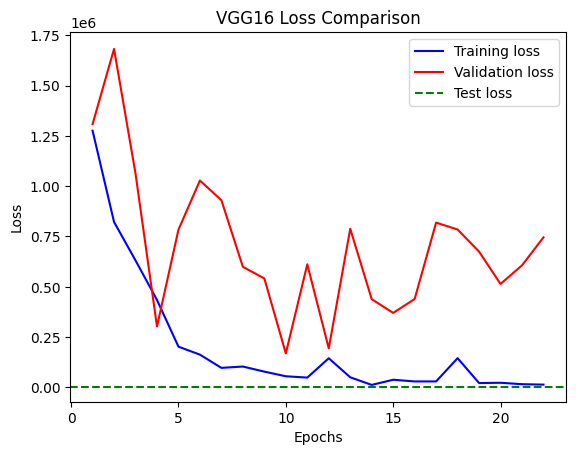

In [ ]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('VGG16 Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

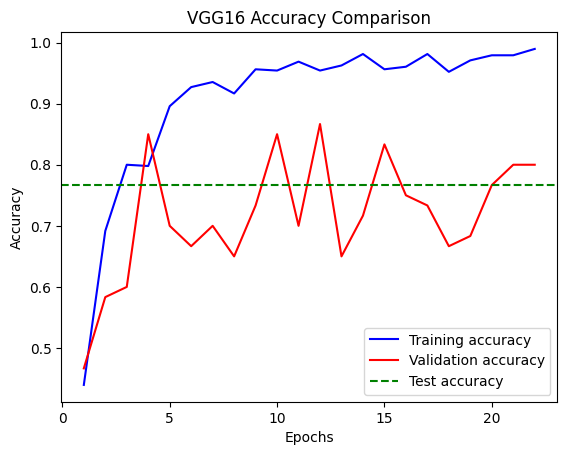

In [ ]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('VGG16 Accuracy Comparison')
plt.xlabel('Epochs')

plt.ylabel('Accuracy')
plt.legend()
plt.show()

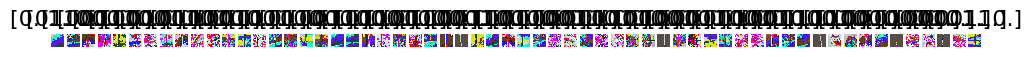

In [ ]:

test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [ ]:
test_labels = test_labels[:,0]
test_labels

array([0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       1., 1., 0., 0., 0., 1., 0., 0., 0.], dtype=float32)

In [ ]:

predictions = model.predict(test_batches, steps=1, verbose=0)

In [ ]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

Confusion matrix, without normalization
[[ 9 20 11]
 [15  4  1]
 [ 0  0  0]]


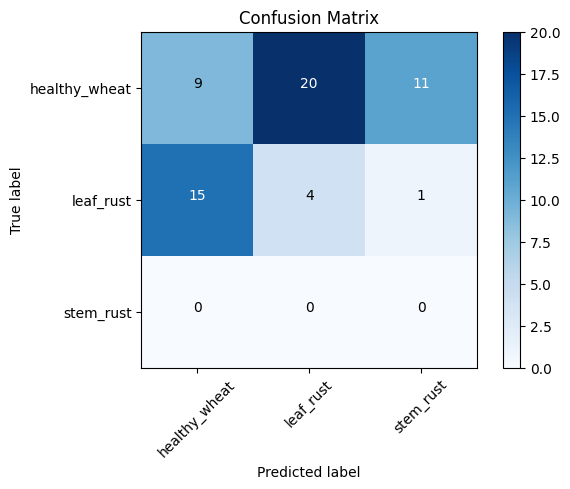

In [ ]:

cm_plot_labels = ['healthy_wheat','leaf_rust','stem_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(test_labels, [np.argmax(i) for i in predictions],target_names=cm_plot_labels,)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(cr)

               precision    recall  f1-score   support

healthy_wheat       0.38      0.23      0.28        40
    leaf_rust       0.17      0.20      0.18        20
    stem_rust       0.00      0.00      0.00         0

     accuracy                           0.22        60
    macro avg       0.18      0.14      0.15        60
 weighted avg       0.31      0.22      0.25        60



In [ ]:
model.evaluate(test_batches)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.7667 - loss: 0.5764


[0.5763875842094421, 0.7666666507720947]